In [1]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import dill
import matplotlib.cm as cm
from matplotlib import colors
from sklearn.metrics.cluster import adjusted_mutual_info_score as ami
from sklearn.metrics.cluster import adjusted_rand_score as ari
import pickle
import sklearn

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print(sklearn.__version__)

1.0.2


In [3]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
fn = '../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad'

In [5]:
sam=SAM()
sam.load_data(fn)

In [6]:
org = 'mo'

In [7]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2',
       'test', 'ss_subclass_threshold_90'],
      dtype='object')

In [8]:
clustering_min = 1
clustering_max = 10
level = 'ss_subclass'

best_ri = 0
t0 = time.time()
all_ri = []
for i in range(clustering_min, clustering_max):
    sam.clustering(param = i/5)
    labeled_data = sam.adata[sam.adata.obs[level] != 'Unlabeled']
    ri = ari(labeled_data.obs[level], labeled_data.obs['leiden_clusters'])
    print(i/5, ri)
    
    if ri > best_ri + .01:
        best_clustering = i/5
        best_ri = ri
    all_ri.append([i/5,ri])
    t1 = time.time()
    print(str(round((i-clustering_min)/clustering_max*100, 2)) + ' percent complete in ' + str(t1 - t0) + ' seconds')

0.2 0.46936043646903486
0.0 percent complete in 3.96004581451416 seconds
0.4 0.6329622080480972
10.0 percent complete in 7.433525562286377 seconds
0.6 0.6356405107996321
20.0 percent complete in 10.80570912361145 seconds
0.8 0.6572581261342381
30.0 percent complete in 14.296002626419067 seconds
1.0 0.6995834959012944
40.0 percent complete in 17.744757413864136 seconds
1.2 0.6693337196935464
50.0 percent complete in 21.130505323410034 seconds
1.4 0.6839406290092203
60.0 percent complete in 24.534637451171875 seconds
1.6 0.7035917572583303
70.0 percent complete in 27.992154836654663 seconds
1.8 0.7076903931944409
80.0 percent complete in 31.487146615982056 seconds


In [9]:
all_ri = np.array(all_ri)

Text(0.5, 0, 'Clustering Resolution')

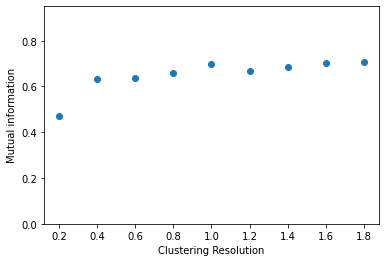

In [10]:
plt.scatter(all_ri[:,0], all_ri[:,1])
plt.ylim(0, .95)
plt.ylabel('Mutual information')
plt.xlabel('Clustering Resolution')
#plt.savefig('Figures_Presentation_09202024/MutInfo_' + org + '.png')

In [11]:
level = 'ss_subclass'

In [12]:
best_clustering

1.0

In [13]:
sam.adata[sam.adata.obs[level] == 'Unlabeled']

View of AnnData object with n_obs × n_vars = 8416 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026', 'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2', 'test', 'ss_subclass_threshold_90'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    o

In [14]:
level = 'ss_subclass'
unmapped_adata = sam.adata[sam.adata.obs[level] == 'Unlabeled']

In [15]:
sam_unmapped=SAM(unmapped_adata)
sam_unmapped.run()
sam_unmapped.clustering(param = 0.4)

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.7497880815768186
Iteration: 2, Convergence: 0.0329640680526597
Computing the UMAP embedding...
Elapsed time: 66.46040368080139 seconds


In [16]:
sam_unmapped.adata.obs['leiden_clusters'].unique()

[5, 0, 23, 6, 9, ..., 22, 28, 19, 26, 27]
Length: 29
Categories (29, int64): [0, 1, 2, 3, ..., 25, 26, 27, 28]

In [17]:
fin_labels = []
new_level = 'test'
for item in sam.adata.obs_names:
    if item in unmapped_adata.obs_names:
        fin_labels.append(org + '_' + str(sam_unmapped.adata.obs.loc[item,'leiden_clusters']))
    else:
        fin_labels.append(sam.adata.obs.loc[item, level])
sam.adata.obs[new_level] = fin_labels

In [ ]:
for item in sam.adata.obs[new_level].unique():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'

In [ ]:
parent_dict['not hypo'] = 'not hypo'

In [20]:
a = 0
b = 0
c = 0
for item in sam.adata.obs[new_level].unique():
    if item[:3] == org + '_':
        b += 1
    else:
        if parent_dict[parent_dict[item]] == 'hypo':
            a += 1
        else:
            c += 1
print(a,b,c, sam.adata.obs[new_level].nunique())

52 41 34 127


In [21]:
np.sort(np.array(sam.adata.obs[new_level].unique()))

array(['014 LA-BLA-BMA-PA Glut', '045 OB-STR-CTX Inh IMN',
       '057 NDB-SI-MA-STRv Lhx8 Gaba', '058 PAL-STR Gaba-Chol',
       '061 STR D1 Gaba', '064 STR-PAL Chst9 Gaba',
       '067 LSX Sall3 Pax6 Gaba', '069 LSX Nkx2-1 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '076 MEA-BST Lhx6 Nfib Gaba',
       '077 CEA-BST Gal Avp Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '084 BST-SI-AAA Six3 Slc22a3 Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', '086 MPO-ADP Lhx8 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba',
       '103 PVHd-DMH Lhx6 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '105 TM

In [22]:
sam.save_anndata(fn)